## What is unsupervised learning?

Unsupervised machine learning is a technique that infers patterns from a dataset without reference to known, or labeled outcomes. It can be used to discover the underlying structure of the data. In effect, you only have "X" variables: there are no "Y" variables! 

With unsupervised learning, there are no "right" answers, like in supervised approaches.  Instead, the algorithm finds how the data groups together, given a list of dimensions (or X variables). **Clustering is an unsupervised technique** that allows you to split a dataset into groups (or "clusters") according to their similarity.

Here is a simple example to understand clustering. Suppose we have two dimensions to consider: income and charitable giving (relative to income).  

### Import the Dataset and display top 5 rows

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('donation.csv')
df.head()

,resp,income,giving
0,1,49060,458
1,2,454440,9638
2,3,51373,11228
3,4,237683,11316
4,5,50572,628


One important point about giving: The amount that you give relative to your income is an important factor.  Someone donating \\$5000 sounds like a saint, but what if they make \\$1M per year?  To address this concern, let's do a little feature engineering (which we will cover soon), and create a donation percentage column:

In [3]:
df['percent of giving']=(df['giving']/df['income'])*100

### Exploratory data analysis.

In [4]:
df.head()

,resp,income,giving,percent of giving
0,1,49060,458,0.933551
1,2,454440,9638,2.120852
2,3,51373,11228,21.855839
3,4,237683,11316,4.760963
4,5,50572,628,1.241794


In [5]:
df.shape

(40, 4)

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
resp,40.0,20.500000,11.690452,1.000000,10.750000,20.500000,30.250000,40.000000
income,40.0,178081.125000,140371.316432,38122.000000,49468.750000,144604.000000,281227.750000,454440.000000
giving,40.0,5297.975000,4880.978609,349.000000,523.250000,4787.000000,9830.000000,11693.000000
percent of giving,40.0,6.003401,7.804273,0.087969,0.622077,1.880685,7.390914,21.855839


So what do we notice? The average income is very high: \\$178K.  The amount of giving is relatively low, at around 3% (\\$5300).  The standard deviation is also very high.  Recall from your basic stats class that about 2/3 of the data are within one standard deviation of the mean.  This means that 2/3 of the data are within \\$178K plus/minus \\$140K.  That covers a lot of ground!

Let's explore some visualizations:

In [170]:
df.isnull().sum()

resp                 0
income               0
giving               0
percent of giving    0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)

<AxesSubplot: xlabel='income', ylabel='Count'>

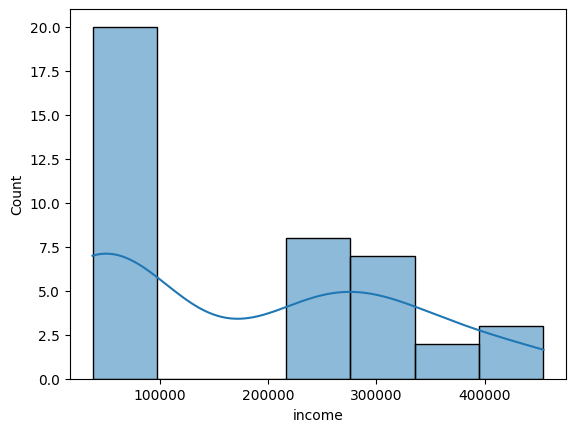

In [172]:
# you can use distplot(df['income']) as well. But, distplot  is a deprecated function and will be removed in a future version.

# The kde parameter enables you to add a “kernel density estimate” line over the top of your histogram.

sns.histplot(df['income'], kde=True)

<Axes: xlabel='giving', ylabel='Count'>

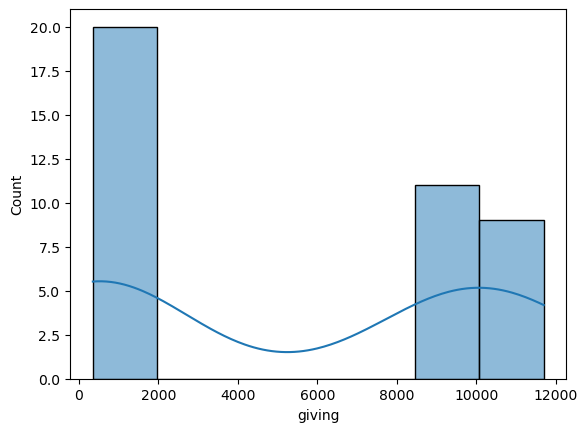

In [8]:
# The kde parameter enables you to add a “kernel density estimate” line over the top of your histogram.

sns.histplot(df['giving'], kde=True)

<Axes: xlabel='percent of giving', ylabel='Count'>

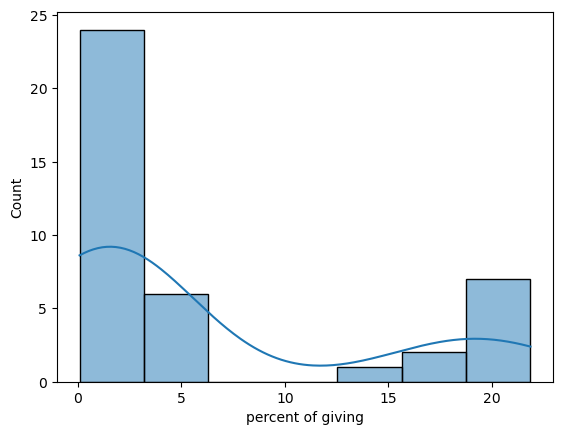

In [9]:
# The kde parameter enables you to add a “kernel density estimate” line over the top of your histogram.

sns.histplot(df['percent of giving'],kde=True)

OK, this is VERY interesting.  Notice that the plots have two peaks?  This is called a "bimodal" distribution, and it means we may have two different populations (or major groups) for both giving and for income. A bimodal distribution is a probability distribution with two different modes.

## EXERCISE 1

a. Create a scatter plot of income vs. giving

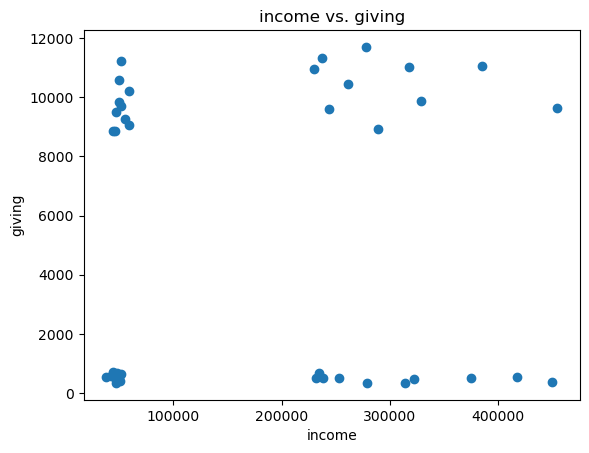

In [10]:
plt.title('income vs. giving')
plt.xlabel('income')
plt.ylabel('giving')
plt.scatter(df['income'],df['giving'])
plt.show()

b. create a scatter plot of  income vs. percent of giving 

## Import Libraries for K-Means clustering

In [11]:
# import the necessary libraries.
import sklearn
import numpy as np

# within sklearn we have sublibrary cluster and within cluster we have a method called Kmeans
from sklearn.cluster import KMeans 

# The following are libraries that allow us to scale the data.
from sklearn.preprocessing import scale, StandardScaler

In [13]:
df2 = df[['income','giving']].copy() # subset the dataframe

## Scale the data
OK, now that we have swum in the data a little, let's import the libraries we need to **scale** and to do the KMeans clustering:

In [14]:
# Cluster analysis requires us to scale the data to eliminate scaling effects in our results
scaler = StandardScaler() #this creates a scaler object
scaled_array = scaler.fit_transform(df2)# returns np array, not dataframe

# if your code gives error, try to run this code too: scaled_array = scaled_array.astype(np.float)

The above requires some review.  To scale the data, you must first create a StandardScaler object (scaler).  The fit_transform method determines the necessary transformation and do the rescaling.

**You should note that the transform method returns a numpy array, not a dataframe.  For that reason, the describe method will not work (it only works on dataframes).**

Note that we will mostly use numpy arrays just before doing analysis.  In general, we will use dataframes to manipulate data or to do plotting or descriptives! Here are the guidelines for when to use both:
* Use dataframes for plotting, descriptives, and data manipulation.  
* Use numpy arrays as input for machine learning algorithms, since they run much faster than dataframes.

In [15]:
df2.head(2)

,income,giving
0,49060,458
1,454440,9638


In [17]:
# Remember [:,0] means all rows and first column!

income_average = scaled_array[:,0].mean()# income is the first column that's why we use 0 index
income_std = scaled_array[:,0].std()
giving_average=scaled_array[:,1].mean() # giving is the second column that's why we use 1 index
giving_std=scaled_array[:,1].std()

#I use the following codes only to illustrate the scales have been transformed to z-scores (mean of 0 and std of 1).

print('income mean is {:.6f}.'.format(income_average))
print('income std is {:.6f}.'.format(income_std))
print('giving mean is {:.6f}.'.format(giving_average))
print('giving std is {:.6f}.'.format(giving_std))

income mean is 0.000000.
income std is 1.000000.
giving mean is -0.000000.
giving std is 1.000000.


## Elbow Curve
**make the elbow curve to see how many clusters you need**

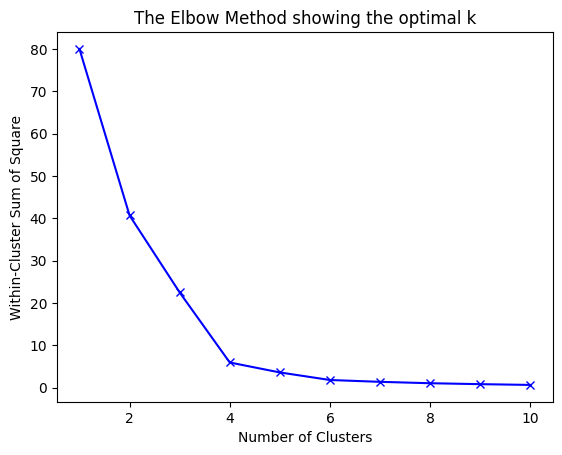

In [182]:
# make the elbow curve to see how many clusters you need
#  wcss( Within-Cluster Sum of Square ) is the sum of squared distance between each point and the centroid in a cluster.
# K-means++  ensures a smarter initialization of the centroids and improves the quality of the clustering. 
# Random state=0 helps to Start with same random data point as centroid if you use Kmeans++ for initializing centroids
# Inertia gets the sum of squared distances of samples to their closest cluster center.

    
wcss=[] 

for i in range(1, 11): # 10 is max number of cluster to display in elbow curve. If you want to see what WCSS will be for more than 10 clusters, you can increase this number.
    kmeans = KMeans(n_clusters=i, init = 'k-means++', random_state = 0) 
    kmeans.fit(scaled_array)
    wcss.append(kmeans.inertia_) 
    
    
plt.plot(range(1, 11), wcss, 'bx-') # bx- will add blue cross sign on the chart
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Square')
plt.title('The Elbow Method showing the optimal k')
plt.show()
#plt.savefig('elbow.png')


  

The "wcss" on the y-axis is the sum of the squared distances of the data points from their assigned centroid.  Think of it this way: we have data on the income and giving rates of 40 people. Assume we had 40 centroids.  The wcss would then be 0, because each person would be its own centroid, and the distance from all centroids would be 0. If we have 20 centroids, we would have a wcss value, but it would be low.   So why not set the number of centroids to be high?  Answer: because it becomes harder to describe the clusters.  In contrast, a lower number of centroids result in a higher wcss, but a more interpretable set of centroids.  With 40 clusters, the result doesn't tell us anything, because each person is its own cluster!

HENCE: The elbow curve plots the wcss vs. the number of clusters (or centroids).  As the number of clusters increase, the wcss will decline (since the points will be closer to a centroid).  But as the number of clusters increase, interpreting the clusters can become more challenging.  

For that reason, we look for the "elbow": the point where the change in the wcss levels out.  As a rule of thumb, this represents the point where the relative value of adding more clusters declines.  

Notes:
* You should use the elbow curve as a *guide*, not a hard rule.  
* Ultimately, it is more important to be able to _interpret_ the clusters, not where the bend is!

## K-Means clustering

In [21]:
# Let's assume four clusters....
# Do K-Means
# from Elbow curver, we decided to have 4 clusters

kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 0) # <-- use random_state = 0  to get my result
kmeans = kmeans.fit(scaled_array) 

In [23]:
# What are the unscaled coordinates of our centroids?
unscaled_centroids = scaler.inverse_transform(kmeans.cluster_centers_)
unscaled_centroids

array([[ 47029.5,    550.9],
       [302558.3,  10449.6],
       [311407.9,    488.5],
       [ 51328.8,   9702.9]])

So what do the above centroids tell us?  Well, recall that a centroid is the middle of a cluster.  It is the point that is EXACTLY equidistant to all other points in the cluster.  This means that the second and third group have a very high income, but the third group's giving is very low relative to the second group.  In contrast, the first and fourth group have relatively low incomes, but the first group gives almost as much as the third group (which has a MUCH higher income).

Let's store the centroids in a new dataframe, called centroids.

In [25]:
# Build a dataframe with the centroid coordinates
centroids = pd.DataFrame({'centroid_income':unscaled_centroids[:,0],'centroid_giving':unscaled_centroids[:,1]})

In [186]:
centroids

,centroid_income,centroid_giving
0,47029.5,550.9
1,302558.3,10449.6
2,311407.9,488.5
3,51328.8,9702.9


Let's store the cluster numbers so that we can reference them later.  The kmeans object that we used has them stored: we just need to know how to access them:

In [27]:
df2['label'] = kmeans.labels_.astype(int) # kmeans labels_ generates the cluster numbers
df2.head(15) # look to see which cluster each row is assigned to

,income,giving,label
0,49060,458,0
1,454440,9638,1
2,51373,11228,3
3,237683,11316,1
4,50572,628,0
5,38122,552,0
6,328515,9854,1
7,384825,11035,1
8,55534,9255,3
9,417465,536,2


Now let's plot the results, which should help us understand our clusters better.  I will use the above labels for the numbers, so that we can see which point belongs to each cluster:

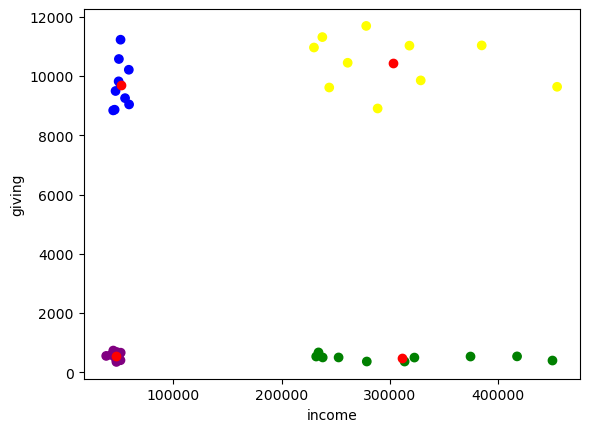

In [29]:
# plot the results using the cluster number as the color
# centroids appear in red

LABEL_COLOR_MAP = {0 : 'purple',1 : 'yellow',2:'green', 3:'blue'}
plt.scatter(df2['income'], df2['giving'], c=df2['label'].map(LABEL_COLOR_MAP)) # (x,y,color)
plt.scatter(centroids['centroid_income'], centroids['centroid_giving'], c='red') # (x,y,color)
plt.xlabel('income')
plt.ylabel('giving')
#plt.savefig('kmeans image')
plt.show()


You can clearly see the four clusters, because they are in yellow, green, blue, and purple.  The centroids (in red) are also included and you can see that they occur in the middle of each centroid.

So in the end, we end up with four clusters:
* PHILANTHROPISTS (BLUE cluster): High income, high giving
* GREEDY (GREEN cluster): High income, low giving 
* SAINTS (YELLOW cluster): Low income, high giving 
* NON-GIVERS (PURPLE cluster): Low income, low giving

Note that in the above, there is no "dependent" variable.  We are creating the names of the clusters, based on how they align in two-dimensional space.  We have the charitable giving and income, but these are both "independent": they arent meant to predict each other.  Instead, they are meant to describe groups according to where they fall along the two dimensions.

## Exercise 2


Right click on the KMeans(donation) notebook, click on Duplicate. Then, you can make changes to the duplicate of this notebook.
In the duplicate notebook, use **'income'** and **'percent of giving'** for clustering the data. 

* Take the screenshot of your clustering and submit on Canvas
* Interpret each cluster.Does your interpretation of the clusters change?